# 02. Validació del model

Aquest notebook avalua la qualitat predictiva del model ELO-Poisson sobre un conjunt de validació temporal (2023–2024) i el compara amb tres models de referència.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson

In [2]:
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.model import expected_goals
from src.elo import simulate_elos_valid
from src.converge import converge_model
from src.grid_search import csv_to_dict, grid_search_optimized, grid_search_parallel

In [3]:
import json
from pathlib import Path

project_root = Path.cwd().parent
json_path = project_root / 'data' / 'raw' / 'team-conf.json'

with open(json_path, 'r', encoding='utf-8') as f:
    team_conf_dict = json.load(f)

In [4]:
df = pd.read_csv("../data/processed/df.csv")
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [5]:
df_train = df[df["date"] < "2023-01-01"]
df_valid = df[df["date"] >= "2023-01-01"]

In [6]:
# En cas de ser primera execución, es pot generar el csv:
# Primer de tot, definim els folds:
df_train_train_fold1 = df[df["date"] < "2015-01-01"]
df_train_valid_fold1 = df[(df["date"] >= "2015-01-01") & (df["date"] < "2017-01-01")]

df_train_train_fold2 = df[df["date"] < "2017-01-01"]
df_train_valid_fold2 = df[(df["date"] >= "2017-01-01") & (df["date"] < "2019-01-01")]

df_train_train_fold3 = df[df["date"] < "2019-01-01"]
df_train_valid_fold3 = df[(df["date"] >= "2019-01-01") & (df["date"] < "2021-01-01")]

df_train_train_fold4 = df[df["date"] < "2021-01-01"]
df_train_valid_fold4 = df[(df["date"] >= "2021-01-01") & (df["date"] < "2023-01-01")]

df_folds = {
    "fold1": (df_train_train_fold1, df_train_valid_fold1),
    "fold2": (df_train_train_fold2, df_train_valid_fold2),
    "fold3": (df_train_train_fold3, df_train_valid_fold3),
    "fold4": (df_train_train_fold4, df_train_valid_fold4)
}

# Segudiament, definim els paràmetres a buscar:
dict_search = {
    'eta' : [0.01, 0.025, 0.05],
    'k_0' : [0.05],
    'intercontinental' : {
        'True' : [1.2, 1.5, 1.7, 2.0],
        'False' : [1.0]
    },
    'stage' : {
        'Qualification' : [1.2, 1.5, 1.7, 2.0],
        'Tournament' : [1.2, 1.5, 1.7, 2.0],
        'Other' : [1.0]
    },
    'competition' : {
        'World_Cup' : [2.5, 3.0, 3.5, 4.0],
        'Continental_Cup' : [1.5, 1.7, 2.0, 2.5],
        'Secundary_Continental_Cup' : [1.0, 1.2, 1.5],
        'International_Cup' : [1.0, 1.2, 1.5],
        'Friendlies' : [1.0]
    }
}

# dict_k, loss = grid_search_parallel(df_folds, team_conf_dict, dict_search)
# df_dict_k = pd.json_normalize(dict_k)
# df_dict_k.to_csv("../results/training/grid_search.csv", index=False)
dict_k = csv_to_dict("../results/training/grid_search_train.csv")

In [7]:
__, df_ranking, df_confs, params, params_se, max_diff_array = converge_model(df_train, team_conf_dict, dict_k, max_iterations=30)

Iniciando convergencia del modelo final...
Iteración 1 (Bootstrap) completada.
Iteración 2 | Máxima variación: 0.057216
Iteración 3 | Máxima variación: 0.046524
Iteración 4 | Máxima variación: 0.037842
Iteración 5 | Máxima variación: 0.030796
Iteración 6 | Máxima variación: 0.025251
Iteración 7 | Máxima variación: 0.020980
Iteración 8 | Máxima variación: 0.017701
Iteración 9 | Máxima variación: 0.015150
Iteración 10 | Máxima variación: 0.013119
Iteración 11 | Máxima variación: 0.011459
Iteración 12 | Máxima variación: 0.010071
Iteración 13 | Máxima variación: 0.008886
Iteración 14 | Máxima variación: 0.007860
Iteración 15 | Máxima variación: 0.006962
Iteración 16 | Máxima variación: 0.006172
Iteración 17 | Máxima variación: 0.005472
Iteración 18 | Máxima variación: 0.004852
Iteración 19 | Máxima variación: 0.004301
Iteración 20 | Máxima variación: 0.003812
Iteración 21 | Máxima variación: 0.003377
Iteración 22 | Máxima variación: 0.002991
Iteración 23 | Máxima variación: 0.002649
Itera

In [17]:
df_params = pd.json_normalize(params)
df_params.to_csv("../results/training/model_params.csv", index=False)

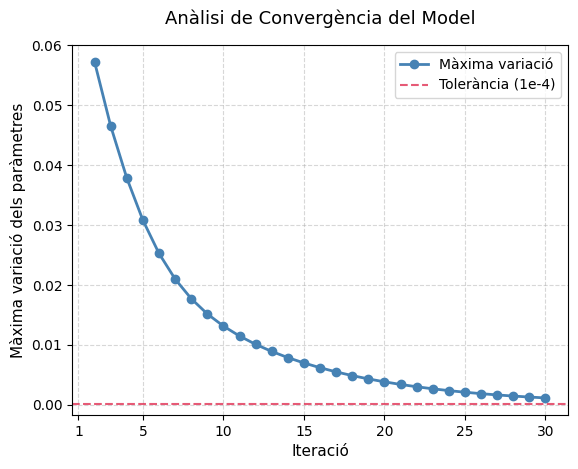

In [8]:
iterations = np.arange(2, 2 + len(max_diff_array))

# 2. Construcción del gráfico (estilo limpio para el TFG)
plt.plot(
    iterations,
    max_diff_array,
    marker="o",
    linestyle="-",
    color="steelblue",
    linewidth=2,
    label="Màxima variació",
)
plt.axhline(
    y=1e-4, color="crimson", linestyle="--", alpha=0.7, label="Tolerància (1e-4)"
)

# 3. Etiquetas y títulos en catalán para la memoria
plt.xlabel("Iteració", fontsize=11)
plt.ylabel("Màxima variació dels paràmetres", fontsize=11)
plt.title(
    "Anàlisi de Convergència del Model", fontsize=13, pad=15
)
plt.xticks([1, 5, 10, 15, 20, 25, 30])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=10)

# 4. Guardar directamente en tu carpeta de figuras de LaTeX
save_path = "../results/training/convergence_plot.png"  # Ajusta la ruta si es necesario
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [9]:
def probabilities_match(lambda_h, lambda_a):
    max_goals = 15

    prob_h = [poisson.pmf(i, lambda_h) for i in range(max_goals)]
    prob_a = [poisson.pmf(i, lambda_a) for i in range(max_goals)]
    
    matrix = np.outer(prob_h, prob_a)
    
    win_h = np.sum(np.tril(matrix, -1)) # i > j
    draw  = np.sum(np.diag(matrix))     # i == j
    win_a = np.sum(np.triu(matrix, 1))  # i < j
    
    return win_h, draw, win_a

In [10]:
def validate_model(df_valid, df_ranking, df_confs, team_conf_dict, params, dict_k):
    n = len(df_valid)
    # 1. Estat inicial des de l'entrenament
    init_team_elos = {
        row["Team"]: {"off": row["Off_ELO"], "def": row["Def_ELO"]}
        for _, row in df_ranking.iterrows()
    }
    init_team_elos["Ticino"] = {"off": 0.0, "def": 0.0}
    init_conf_elos = dict(zip(df_confs["Confederation"], df_confs["Meta_ELO"]))
    
    # 2. Simulació online (ja inclou re-centrat anual!)
    df_valid_res, df_elos, df_confs = simulate_elos_valid(df_valid, team_conf_dict, dict_k, params, dict_k['eta'], init_team_elos, init_conf_elos)
    
    # 3. Càlcul de lambdas vectoritzat
    h_adv = 1 - df_valid_res["neutral"].values
    diff_gamma = (df_valid_res["Home_Conf_ELO"] - df_valid_res["Away_Conf_ELO"]).values
    
    lambda_home = expected_goals(params, 
                                  df_valid_res["Home_Offensive_ELO"].values,
                                  df_valid_res["Away_Defensive_ELO"].values,
                                  h_adv, diff_gamma)
    lambda_away = expected_goals(params,
                                  df_valid_res["Away_Offensive_ELO"].values,
                                  df_valid_res["Home_Defensive_ELO"].values,
                                  -h_adv, -diff_gamma)
    
    # 4. BS i LL
    home_goals = df_valid_res["home_score"].values
    away_goals = df_valid_res["away_score"].values
    
    predictions = np.zeros((n, 3))   # [P(H), P(D), P(A)]
    outcomes = np.zeros((n, 3))

    brier_total = 0.0
    log_loss_total = 0.0
    rps_total = 0.0

    eps = 1e-15
    
    for i in range(len(df_valid_res)):
        win_h, draw, win_a = probabilities_match(lambda_home[i], lambda_away[i])
        predictions[i] = [win_h, draw, win_a]
        
        if home_goals[i] > away_goals[i]:
            outcomes[i] = [1, 0, 0]
            p_actual = win_h
        elif home_goals[i] == away_goals[i]:
            outcomes[i] = [0, 1, 0]
            p_actual = draw
        else:
            outcomes[i] = [0, 0, 1]
            p_actual = win_a
        
        brier_total += np.sum((predictions[i] - outcomes[i])**2)
        log_loss_total += -np.log(max(p_actual, eps))

        cum_pred = np.cumsum(predictions[i])
        cum_out = np.cumsum(outcomes[i])
        rps_total += np.sum((cum_pred[:-1] - cum_out[:-1])**2) / 2

    
    return {
        "brier_score": brier_total / n,
        "log_loss": log_loss_total / n,
        "rps": rps_total / n,
        "predictions": predictions,
        "outcomes": outcomes
    }

In [11]:
validation = validate_model(df_valid, df_ranking, df_confs, team_conf_dict, params, dict_k)

Gràfic desat amb èxit a: C:/Users/sergi/Desktop/TFG/figures\reliability_home.png


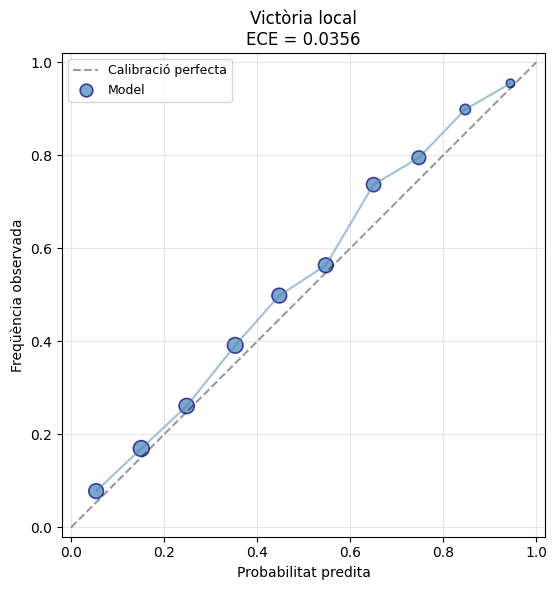

Gràfic desat amb èxit a: C:/Users/sergi/Desktop/TFG/figures\reliability_draw.png


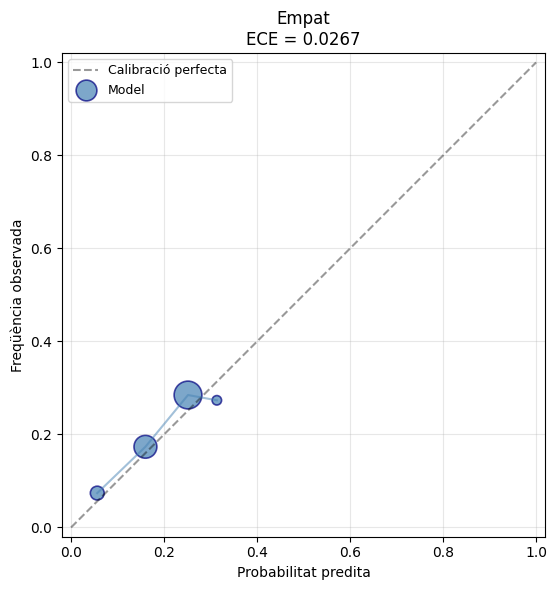

Gràfic desat amb èxit a: C:/Users/sergi/Desktop/TFG/figures\reliability_away.png


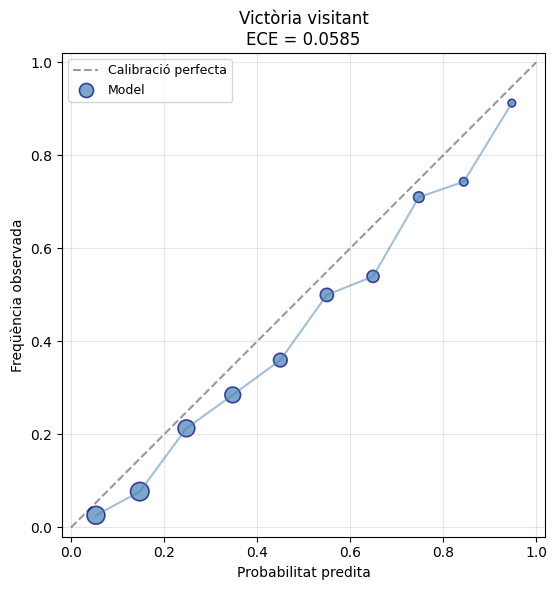


--- RESUM DE MÈTRIQUES ECE ---
ECE Victòria local:     0.0356
ECE Empat:              0.0267
ECE Victòria visitant:  0.0585
ECE mitjana global:     0.0403


In [12]:
def reliability_diagram(
    predictions,
    outcomes,
    n_bins=10,
    labels=("Victòria local", "Empat", "Victòria visitant"),
    save_dir="C:/Users/sergi/Desktop/TFG/figures",
):
    """Genera i desa reliability diagrams individuals per a les 3 classes del model.

    predictions: array (N, 3) amb les probabilitats predites
    outcomes:    array (N, 3) one-hot dels resultats reals
    save_dir:    Directori on es desaran les 3 imatges per separat
    """
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    eces = []
    # Sufixos per als noms dels fitxers d'acord amb la teva estructura de LaTeX
    file_suffixes = ["home", "draw", "away"]

    for idx, (label, suffix) in enumerate(zip(labels, file_suffixes)):
        # Creem una figura independent per a cada gràfic per poder-los desar per separat
        fig, ax = plt.subplots(figsize=(6, 6))

        p_pred = predictions[:, idx]
        p_obs = outcomes[:, idx]

        mean_predicted = []
        mean_observed = []
        counts = []

        ece = 0.0
        N = len(p_pred)

        for i in range(n_bins):
            if i == n_bins - 1:
                mask = (p_pred >= bins[i]) & (p_pred <= bins[i + 1])
            else:
                mask = (p_pred >= bins[i]) & (p_pred < bins[i + 1])

            n_bin = mask.sum()
            if n_bin > 0:
                mp = p_pred[mask].mean()
                mo = p_obs[mask].mean()
                mean_predicted.append(mp)
                mean_observed.append(mo)
                counts.append(n_bin)
                ece += (n_bin / N) * abs(mp - mo)

        eces.append(ece)

        mean_predicted = np.array(mean_predicted)
        mean_observed = np.array(mean_observed)
        counts = np.array(counts)

        # 1. Línia diagonal de calibració perfecta
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Calibració perfecta")

        # 2. Línia del model
        ax.plot(
            mean_predicted,
            mean_observed,
            "-",
            color="steelblue",
            alpha=0.5,
            linewidth=1.5,
        )

        # 3. Punts (mida proporcional al nombre d'observacions de cada bin)
        ax.scatter(
            mean_predicted,
            mean_observed,
            s=np.clip(counts / 3, 30, 400),
            alpha=0.7,
            color="steelblue",
            edgecolors="navy",
            linewidth=1.2,
            label="Model",
        )

        # Decoració del plot individual
        ax.set_xlabel("Probabilitat predita", fontsize=10)
        ax.set_ylabel("Freqüència observada", fontsize=10)
        ax.set_title(f"{label}\nECE = {ece:.4f}", fontsize=12)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.legend(loc="upper left", fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_aspect("equal")

        plt.tight_layout()

        # 4. Desament individual del fitxer
        if save_dir:
            # Creem la carpeta si no existeix per evitar errors de ruta
            os.makedirs(save_dir, exist_ok=True)
            # Nom de sortida: ex: reliability_home.png
            full_path = os.path.join(save_dir, f"reliability_{suffix}.png")
            plt.savefig(full_path, dpi=300, bbox_inches="tight")
            print(f"Gràfic desat amb èxit a: {full_path}")

        plt.show()
        plt.close()  # Tanquem la figura per alliberar memòria

    return eces


# ==========================================
# EXECUTAR LA FUNCIÓ
# ==========================================
# Pots passar directament la ruta de la teva estructura de carpetes
eces = reliability_diagram(
    validation["predictions"],
    validation["outcomes"],
    n_bins=10)

print(f"\n--- RESUM DE MÈTRIQUES ECE ---")
print(f"ECE Victòria local:     {eces[0]:.4f}")
print(f"ECE Empat:              {eces[1]:.4f}")
print(f"ECE Victòria visitant:  {eces[2]:.4f}")
print(f"ECE mitjana global:     {np.mean(eces):.4f}")

In [13]:
def baseline_constants(df_train, df_valid):
    home_wins = (df_train['home_score'] > df_train['away_score']).mean()
    draws = (df_train['home_score'] == df_train['away_score']).mean()
    away_wins = 1 - home_wins - draws
    print(f"Probabilitat constant victòria local: {home_wins:.4f}")
    print(f"Probabilitat constant empat: {draws:.4f}")
    print(f"Probabilitat constant victòria visitant: {away_wins:.4f}")
    print(f"Nombre d'observacions: {len(df_valid)}")
    n = len(df_valid)

    return np.tile([home_wins, draws, away_wins], (n, 1))

def baseline_poisson_constant(df_train, df_valid):
    """Poisson amb λ constant (mitjana global de gols)."""
    lambda_h = df_train['home_score'].mean()
    lambda_a = df_train['away_score'].mean()
    
    p_h, p_d, p_a = probabilities_match(lambda_h, lambda_a)
    
    n = len(df_valid)
    return np.tile([p_h, p_d, p_a], (n, 1))

def baseline_classical_elo(df_train, df_valid, K=20, HFA=100, initial_rating=1500):
    """ELO clàssic: un sol ràting per equip, fórmula logística estàndard."""
    
    # Inicialitzar ràtings de tots els equips
    teams = pd.concat([df_train['home'], df_train['away'],
                       df_valid['home'], df_valid['away']]).unique()
    ratings = {t: initial_rating for t in teams}
    
    # Entrenar amb df_train
    for _, match in df_train.iterrows():
        h, a = match['home'], match['away']
        hg, ag = match['home_score'], match['away_score']
        h_advantage = 0 if match['neutral'] else HFA
        
        E_h = 1 / (1 + 10**((ratings[a] - ratings[h] - h_advantage) / 400))
        E_a = 1 - E_h
        
        if hg > ag:    S_h, S_a = 1, 0
        elif hg == ag: S_h, S_a = 0.5, 0.5
        else:          S_h, S_a = 0, 1
        
        ratings[h] += K * (S_h - E_h)
        ratings[a] += K * (S_a - E_a)
    
    # Probabilitat de empat constant (estimada de l'entrenament)
    p_draw_const = (df_train['home_score'] == df_train['away_score']).mean()
    
    # Predir sobre df_valid amb actualització online
    n = len(df_valid)
    predictions = np.zeros((n, 3))
    
    for i in range(n):
        match = df_valid.iloc[i]
        h, a = match['home'], match['away']
        h_advantage = 0 if match['neutral'] else HFA
        
        # Predicció abans d'actualitzar
        E_h = 1 / (1 + 10**((ratings[a] - ratings[h] - h_advantage) / 400))
        
        p_h = (1 - p_draw_const) * E_h
        p_d = p_draw_const
        p_a = (1 - p_draw_const) * (1 - E_h)
        predictions[i] = [p_h, p_d, p_a]
        
        # Actualització després de la predicció
        hg, ag = match['home_score'], match['away_score']
        if hg > ag:    S_h, S_a = 1, 0
        elif hg == ag: S_h, S_a = 0.5, 0.5
        else:          S_h, S_a = 0, 1
        
        ratings[h] += K * (S_h - E_h)
        ratings[a] += K * (S_a - (1 - E_h))
    
    return predictions

In [14]:
def compute_all_metrics(predictions, outcomes, n_bins=10):
    """Calcula BS, LL, RPS i ECE mitjana d'un conjunt de prediccions."""
    n = len(predictions)
    eps = 1e-15
    
    # Brier Score
    brier = np.mean(np.sum((predictions - outcomes)**2, axis=1))
    
    # Log-loss
    p_actual = np.sum(predictions * outcomes, axis=1)
    log_loss = -np.mean(np.log(np.maximum(p_actual, eps)))
    
    # RPS
    cum_pred = np.cumsum(predictions, axis=1)
    cum_out = np.cumsum(outcomes, axis=1)
    rps = np.mean(np.sum((cum_pred[:, :-1] - cum_out[:, :-1])**2, axis=1)) / 2
    
    # ECE mitjana
    eces = []
    bins = np.linspace(0, 1, n_bins + 1)
    for c in range(3):
        p_pred, p_obs = predictions[:, c], outcomes[:, c]
        ece = 0
        for j in range(n_bins):
            mask = (p_pred >= bins[j]) & (p_pred < bins[j+1])
            if mask.sum() > 0:
                ece += (mask.sum() / n) * abs(p_pred[mask].mean() - p_obs[mask].mean())
        eces.append(ece)
    
    return {"Brier": brier, "LL": log_loss, "RPS": rps, "ECE": np.mean(eces)}

In [15]:
# 1. Outcomes one-hot del df_valid
n = len(df_valid)
outcomes = np.zeros((n, 3))
hg = df_valid['home_score'].values
ag = df_valid['away_score'].values
outcomes[hg > ag, 0] = 1
outcomes[hg == ag, 1] = 1
outcomes[hg < ag, 2] = 1

# 2. Generar prediccions per a cada model
print("Calculant baselines...")
predictions = {
    "Constants":                          baseline_constants(df_train, df_valid),
    "Poisson λ constant":                  baseline_poisson_constant(df_train, df_valid),
    "ELO clàssic":                         baseline_classical_elo(df_train, df_valid),
    "ELO-Poisson bivariant (proposat)":    validation["predictions"],
}

# 3. Calcular mètriques de cada model
comparison = pd.DataFrame({
    name: compute_all_metrics(preds, outcomes)
    for name, preds in predictions.items()
}).T

print(comparison.round(4))

# 4. Guardar per al TFG
# comparison.to_csv('../results/validation_comparison.csv')

Calculant baselines...
Probabilitat constant victòria local: 0.4852
Probabilitat constant empat: 0.2373
Probabilitat constant victòria visitant: 0.2775
Nombre d'observacions: 3013
                                   Brier      LL     RPS     ECE
Constants                         0.6384  1.0573  0.2297  0.0146
Poisson λ constant                0.6415  1.0625  0.2312  0.0332
ELO clàssic                       0.5360  0.9109  0.1785  0.0472
ELO-Poisson bivariant (proposat)  0.5065  0.8628  0.1666  0.0403


In [16]:
from scipy.stats import norm


table_rows = []
for name in ['alpha', 'beta_1', 'beta_2', 'theta', 'gamma']:
    estimate = params[name]
    se = params_se[f'{name}_se']
    z = estimate / se
    p_value = 2 * (1 - norm.cdf(abs(z)))   # test de Wald bilateral
    table_rows.append({
        'param': name,
        'estimate': estimate,
        'se': se,
        'z': z,
        'p_value': p_value
    })

df_coef = pd.DataFrame(table_rows)
print(df_coef.round(8))

    param  estimate        se          z   p_value
0   alpha  0.152693  0.005395  28.300817  0.000000
1  beta_1  0.067593  0.000928  72.802194  0.000000
2  beta_2 -0.098683  0.001114 -88.567497  0.000000
3   theta  0.437214  0.009236  47.336629  0.000000
4   gamma  0.021063  0.010105   2.084372  0.037126
